### Download Dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e9')

print("Path to competition files:", path)

d:\ML_AI\PROJECT_2083\LEARN\ELECTRIC_CAR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to competition files: C:\Users\Bijay\.cache\kagglehub\competitions\playground-series-s6e9


In [2]:
import os

os.listdir(path)

['sample_submission.csv', 'test.csv', 'train.csv']

In [3]:
traind_path = os.path.join(path, 'train.csv')

### Load Dataset

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
sample_sub = pd.read_csv(os.path.join(path, 'sample_submission.csv'))
sample_sub.head()

test_df = pd.read_csv(os.path.join(path, 'test.csv'))

In [6]:
train_df = pd.read_csv(traind_path)
train_df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [7]:
print(train_df.shape)
print(train_df.info())

(668665, 15)
<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 1

In [8]:
print(train_df.isna().sum())
print(train_df.duplicated().sum())

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64
0


In [9]:
train_df['Will_Buy_EV'].value_counts(normalize=True) * 100

Will_Buy_EV
No     82.5355
Yes    17.4645
Name: proportion, dtype: float64

#### Initial Deduction

- Has shape of (668665, 15)

- No Duplicates or null values

- Cat cols: 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'

- Numerical cols: 'Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level'

- id col can be dropped

- target col: Will_Buy_EV(is yes/no. need to convert to numeric) and imbalanced

### EDA

In [10]:
cat_cols = ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 
            'Subsidy_Available', 'Range_Anxiety_Level']

numeric_cols = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 
                'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 
                'Environmental_Concern_Level']

#### Cat cols

In [11]:
for col in cat_cols:
    print(col, train_df[col].unique().to_numpy(), '\n')

Gender ['Male' 'Female' 'Other'] 

City_Type ['Suburban' 'Rural' 'Urban'] 

Current_Car_Type ['Sedan' 'SUV' 'Hatchback' 'Truck'] 

Home_Charging_Possible ['Yes' 'No'] 

Subsidy_Available ['No' 'Yes'] 

Range_Anxiety_Level ['Low' 'Medium' 'High'] 



- nominal: Gender, Current_Car_Type, 
- mapping(yes/no): Home_Charging_Possible, Subsidy_Available 
- ordinal: City_Type, Range_Anxiety_Level 

#### Numeric cols

In [12]:
train_df[numeric_cols].skew()

Age                           -0.003786
Annual_Income_USD             -0.013086
Daily_Commute_km              -0.084589
Number_of_Cars_Owned           0.814497
Charging_Stations_Near_Home    0.698730
Charging_Stations_Near_Work    0.700188
Environmental_Concern_Level    0.054283
dtype: float64

In [13]:
train_df[numeric_cols].describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Annual_Income_USD'}>,
        <Axes: title={'center': 'Daily_Commute_km'}>],
       [<Axes: title={'center': 'Number_of_Cars_Owned'}>,
        <Axes: title={'center': 'Charging_Stations_Near_Home'}>,
        <Axes: title={'center': 'Charging_Stations_Near_Work'}>],
       [<Axes: title={'center': 'Environmental_Concern_Level'}>,
        <Axes: >, <Axes: >]], dtype=object)

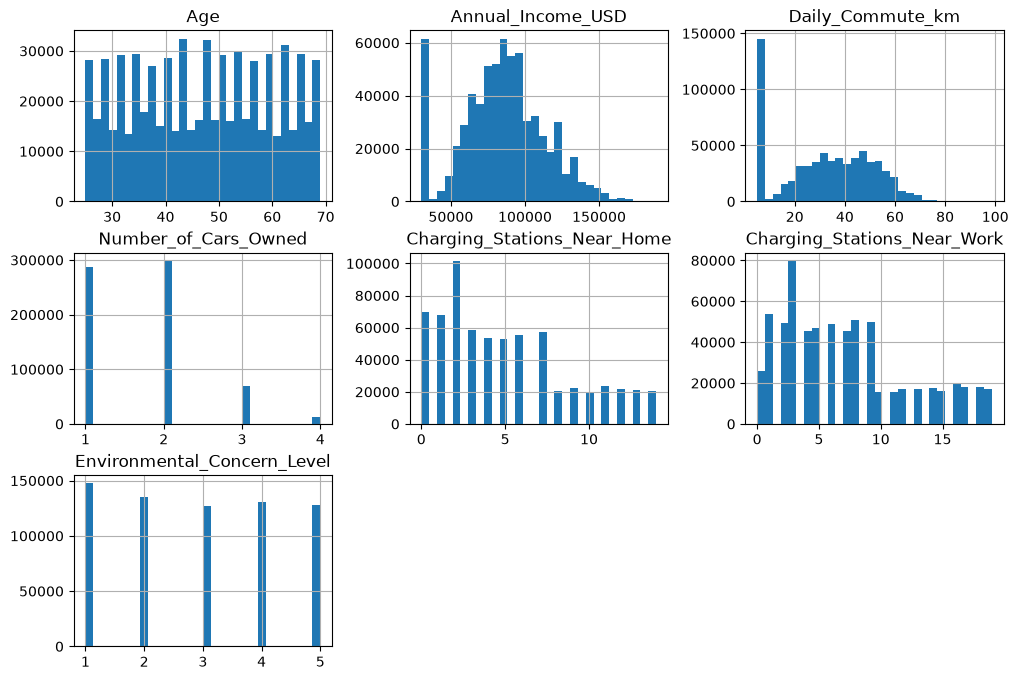

In [14]:
train_df[numeric_cols].hist(figsize=(12, 8), bins=30)

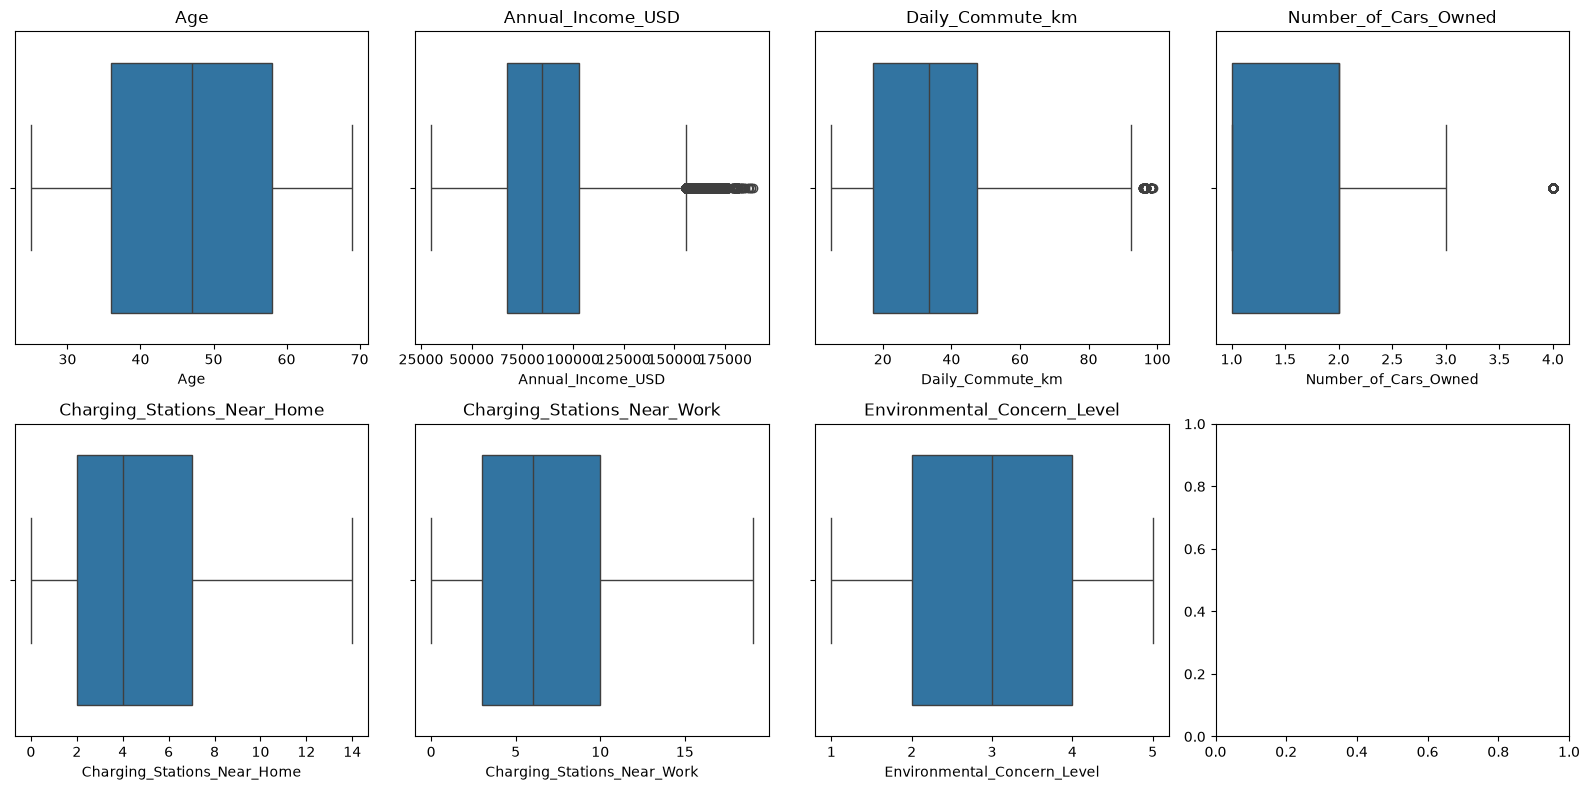

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, col in zip(axes.flat ,numeric_cols):
    sns.boxplot(data=train_df, x=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [16]:
train_df['Annual_Income_USD'].quantile([0.01, 0.05, 0.95, 0.99]) 

0.01     30000.0
0.05     30000.0
0.95    132902.0
0.99    151159.0
Name: Annual_Income_USD, dtype: float64

#### Target relation

In [17]:
train_df.groupby('Will_Buy_EV')[numeric_cols].mean()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
Will_Buy_EV,,,,,,,
No,47.083293,81794.588556,32.553478,1.711319,4.989947,7.205490,2.630395
Yes,46.830654,98827.302948,30.290714,1.718802,4.820807,7.038432,4.377268


In [18]:
for col in cat_cols:
    print(train_df.groupby(col)['Will_Buy_EV'].value_counts(normalize=True).unstack(), '\n')

Will_Buy_EV        No       Yes
Gender                         
Female       0.822359  0.177641
Male         0.827747  0.172253
Other        0.826268  0.173732 

Will_Buy_EV        No       Yes
City_Type                      
Rural        0.806611  0.193389
Suburban     0.819064  0.180936
Urban        0.838942  0.161058 

Will_Buy_EV             No       Yes
Current_Car_Type                    
Hatchback         0.825701  0.174299
SUV               0.819047  0.180953
Sedan             0.828033  0.171967
Truck             0.843587  0.156413 

Will_Buy_EV                   No       Yes
Home_Charging_Possible                    
No                      0.872915  0.127085
Yes                     0.804181  0.195819 

Will_Buy_EV              No       Yes
Subsidy_Available                    
No                 0.994243  0.005757
Yes                0.725305  0.274695 

Will_Buy_EV                No       Yes
Range_Anxiety_Level                    
High                 0.998633  0.001367
Low 

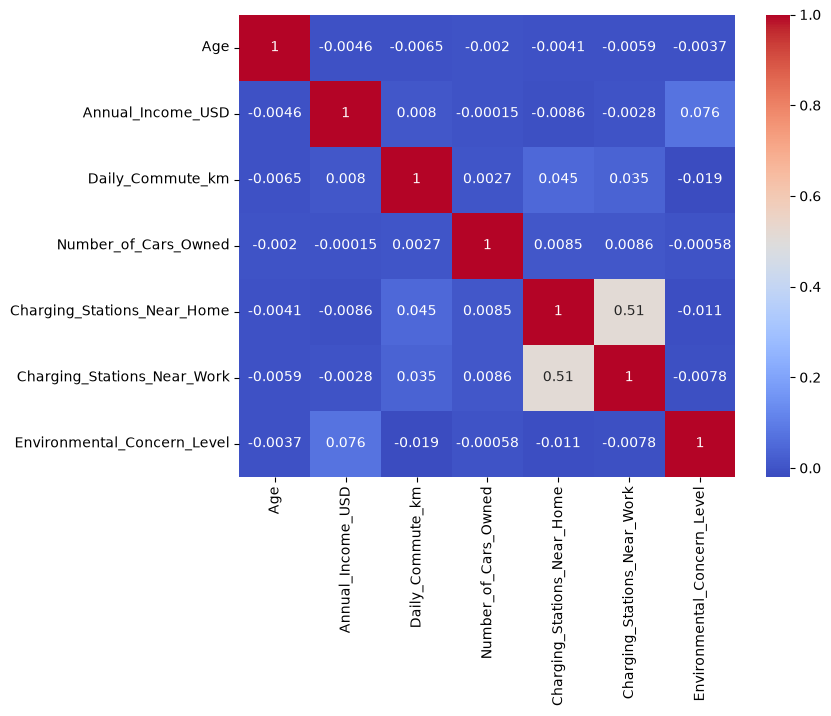

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

In [20]:
train_df.columns

Index(['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='str')

#### Conclusion

- Numeric cols clean but multiple cols seems to be generated rather than natural.
- Some numeric cols have moderate skew while other are roughly symmetrical.
- From cat cols 'Subsidy_Available' and 'Range_Anxiety_Level' are strongest pred and 'Gender' was the weakest.
- From sns, none have a high corr. all < ~0.5
- Numeric col 'Annual_Income_USD' seems to have a outlier but looks like a natural tail

### Preprocessing

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [22]:
nominal_cols = ['Gender', 'Current_Car_Type']
binary_cols = ['Home_Charging_Possible', 'Subsidy_Available']
ordinal_cols = ['City_Type', 'Range_Anxiety_Level']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_cols),
    ('bin', OrdinalEncoder(categories=[['No', 'Yes'], ['No', 'Yes']]), binary_cols),
    ('ord', OrdinalEncoder(categories=[['Rural', 'Suburban', 'Urban'], ['Low', 'Medium', 'High']]), ordinal_cols),
])

In [23]:
X = train_df.drop(columns=['id', 'Will_Buy_EV'])
y = train_df['Will_Buy_EV'].map({'No': 0, 'Yes': 1})

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### Model Training

#### reusable submission

In [24]:
def make_submission(pipeline, test_df, sample_sub, filename):
    X_test = test_df.drop(columns=['id'])
    probs = pipeline.predict_proba(X_test)[:, 1]

    submission = sample_sub.copy()
    submission['Will_Buy_EV'] = probs
    submission.to_csv(filename, index=False)
    print(f"Saved: {filename}, shape: {submission.shape}")

submission_dir = 'submission'
os.makedirs(submission_dir, exist_ok=True)

#### reusable train and eval

In [25]:
def train_and_eval(model, name, preprocessor, X_train, X_val, y_train, y_val):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_val)
    auc = roc_auc_score(y_val, pipe.predict_proba(X_val)[:, 1])

    print(f"{name}: \n")
    print(f"Classification report:\n {classification_report(y_val, y_pred)}\n")
    print(f"Confusion matrix:\n {confusion_matrix(y_val, y_pred)}\n")
    print(f"ROC AUC Score:\n {auc}")

    return pipe, auc

#### Logistic

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr_pipe, lr_auc = train_and_eval(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    "LogisticRegression", preprocessor, X_train, X_val, y_train, y_val
)

LogisticRegression: 

Classification report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.91    110377
           1       0.56      0.90      0.69     23356

    accuracy                           0.86    133733
   macro avg       0.77      0.87      0.80    133733
weighted avg       0.90      0.86      0.87    133733


Confusion matrix:
 [[93623 16754]
 [ 2428 20928]]

ROC AUC Score:
 0.9379349056941424


In [27]:
make_submission(lr_pipe, test_df, sample_sub, os.path.join(submission_dir, 'submission_lr.csv'))

Saved: submission\submission_lr.csv, shape: (286571, 2)


#### Randomforest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe, rf_auc = train_and_eval(
    RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=42),
    "RandomForest", preprocessor, X_train, X_val, y_train, y_val
)

RandomForest: 

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93    110377
           1       0.63      0.80      0.70     23356

    accuracy                           0.88    133733
   macro avg       0.79      0.85      0.82    133733
weighted avg       0.90      0.88      0.89    133733


Confusion matrix:
 [[99312 11065]
 [ 4647 18709]]

ROC AUC Score:
 0.934834549466372


#### Lightgbm

In [29]:
from lightgbm import LGBMClassifier 

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgbm_pipe, lgbm_auc = train_and_eval(
    LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight),
    "LightGBM", preprocessor, X_train, X_val, y_train, y_val
)

[LightGBM] [Info] Number of positive: 93423, number of negative: 441509
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 628
[LightGBM] [Info] Number of data points in the train set: 534932, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174645 -> initscore=-1.553061
[LightGBM] [Info] Start training from score -1.553061
LightGBM: 

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.90    110377
           1       0.55      0.91      0.68     23356

    accuracy                           0.85    133733
   macro avg       0.76      0.88      0.79    133733
weighted avg       0.90      0.85      0.86    133733


Confusion matrix:
 [[92582 17795]
 [ 2005 21351]]

ROC AUC Score:
 0.94097476

#### XGBoost

In [30]:
from xgboost import XGBClassifier

xgb_pipe, xgb_auc = train_and_eval(
    XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, eval_metric='auc'),
    "XGBoost", preprocessor, X_train, X_val, y_train, y_val
)

XGBoost: 

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.91    110377
           1       0.55      0.91      0.69     23356

    accuracy                           0.86    133733
   macro avg       0.76      0.88      0.80    133733
weighted avg       0.90      0.86      0.87    133733


Confusion matrix:
 [[93154 17223]
 [ 2119 21237]]

ROC AUC Score:
 0.940903508398468


#### CatBoost

In [31]:
from catboost import CatBoostClassifier

cat_pipe, cat_auc = train_and_eval(
    CatBoostClassifier(random_state=42, scale_pos_weight=scale_pos_weight, verbose=0),
    "CatBoost", preprocessor, X_train, X_val, y_train, y_val
)

CatBoost: 

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.85      0.91    110377
           1       0.55      0.91      0.69     23356

    accuracy                           0.86    133733
   macro avg       0.77      0.88      0.80    133733
weighted avg       0.90      0.86      0.87    133733


Confusion matrix:
 [[93360 17017]
 [ 2177 21179]]

ROC AUC Score:
 0.9410070142560171


#### Hypertune

In [32]:
# from sklearn.model_selection import RandomizedSearchCV

# param_dist = {
#     "model__n_estimators": [100, 200, 300, 500],
#     "model__learning_rate": [0.01, 0.05, 0.1],
#     "model__num_leaves": [15, 31, 63],
#     "model__max_depth": [-1, 5, 10],
#     "model__min_child_samples": [10, 20, 50],
# }

# lgbm_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight))
# ])

# search = RandomizedSearchCV(
#     lgbm_pipeline, param_distributions=param_dist,
#     n_iter=20, scoring="roc_auc", cv=3, random_state=42, n_jobs=-1
# )

# search.fit(X_train, y_train)
# print(search.best_params_)
# print(search.best_score_)

In [33]:
# best_lgbm = search.best_estimator_
# val_auc = roc_auc_score(y_val, best_lgbm.predict_proba(X_val)[:, 1])
# print(val_auc)

In [34]:
# make_submission(best_lgbm, test_df, sample_sub, os.path.join(submission_dir, 'submission_tuned.csv'))

### Noise Check

In [35]:
def add_noise(df, seed):
    out = df.copy()
    out['_noise'] = np.random.default_rng(seed).random(len(df))
    return out

X_train_noise = add_noise(X_train, seed=101)
X_val_noise = add_noise(X_val, seed=202)

noise_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols + ['_noise']),
    ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_cols),
    ('bin', OrdinalEncoder(categories=[['No', 'Yes'], ['No', 'Yes']]), binary_cols),
    ('ord', OrdinalEncoder(categories=[['Rural', 'Suburban', 'Urban'], ['Low', 'Medium', 'High']]), ordinal_cols),
])

noise_pipe, noise_auc = train_and_eval(
    LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight),
    "LightGBM + noise", noise_preprocessor, X_train_noise, X_val_noise, y_train, y_val
)

print(f"baseline AUC: {lgbm_auc:.5f}")
print(f"with noise:   {noise_auc:.5f}")
print(f"noise bar:    {abs(lgbm_auc - noise_auc):.5f}")


[LightGBM] [Info] Number of positive: 93423, number of negative: 441509
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 883
[LightGBM] [Info] Number of data points in the train set: 534932, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174645 -> initscore=-1.553061
[LightGBM] [Info] Start training from score -1.553061
LightGBM + noise: 

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.90    110377
           1       0.55      0.91      0.68     23356

    accuracy                           0.85    133733
   macro avg       0.76      0.88      0.79    133733
weighted avg       0.90      0.85      0.87    133733


Confusion matrix:
 [[92644 17733]
 [ 2034 21322]]

ROC AUC Score:
 0.

In [36]:
lgbm_bigbin_pipe, lgbm_bigbin_auc = train_and_eval(
    LGBMClassifier(
        random_state=42, scale_pos_weight=scale_pos_weight,
        max_bin=511,
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        max_depth=5, min_child_samples=50
    ),
    "LightGBM tuned + max_bin=511", preprocessor, X_train, X_val, y_train, y_val
)

print(f"baseline (max_bin=255):  {lgbm_auc:.5f}")
print(f"max_bin=511:             {lgbm_bigbin_auc:.5f}")
print(f"change:                  {lgbm_bigbin_auc - lgbm_auc:+.5f}")
print(f"noise bar:               0.00008")

[LightGBM] [Info] Number of positive: 93423, number of negative: 441509
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1140
[LightGBM] [Info] Number of data points in the train set: 534932, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174645 -> initscore=-1.553061
[LightGBM] [Info] Start training from score -1.553061
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [37]:
make_submission(lgbm_bigbin_pipe, test_df, sample_sub, os.path.join(submission_dir, 'submission_maxbin.csv'))

Saved: submission\submission_maxbin.csv, shape: (286571, 2)


In [38]:
# search.fit(X_train, y_train)  # commented out - already ran, took a while
# best result: {'model__num_leaves': 63, 'model__n_estimators': 500, 
#               'model__min_child_samples': 50, 'model__max_depth': 5, 
#               'model__learning_rate': 0.05}, AUC 0.9414

best_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        random_state=42, scale_pos_weight=scale_pos_weight,
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        max_depth=5, min_child_samples=50
    ))
]).fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 93423, number of negative: 441509
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 628
[LightGBM] [Info] Number of data points in the train set: 534932, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174645 -> initscore=-1.553061
[LightGBM] [Info] Start training from score -1.553061
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

### Improvements

In [39]:
from sklearn.model_selection import StratifiedKFold

def run_cv(model, X, y, X_test, preprocessor, n_splits=5, seed=42, label="model"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

        pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        pipe.fit(X_tr, y_tr)

        fold_pred = pipe.predict_proba(X_va)[:, 1]
        oof_preds[val_idx] = fold_pred
        test_preds += pipe.predict_proba(X_test)[:, 1] / n_splits

        fold_auc = roc_auc_score(y_va, fold_pred)
        fold_aucs.append(fold_auc)
        print(f"Fold {fold}: AUC = {fold_auc:.5f}")

    oof_auc = roc_auc_score(y, oof_preds)
    print(f"\nMean fold AUC: {np.mean(fold_aucs):.5f}")
    print(f"Pooled OOF AUC: {oof_auc:.5f}")

    return oof_preds, test_preds, oof_auc

In [40]:
X_test = test_df.drop(columns=['id'])

In [41]:
lgbm_oof, lgbm_test_pred, lgbm_auc = run_cv(
    LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight, max_bin=511,
                    n_estimators=500, learning_rate=0.05, num_leaves=63,
                    max_depth=5, min_child_samples=50, verbose=-1),
    X, y, X_test, preprocessor, label="LightGBM"
)

Fold 1: AUC = 0.94101
Fold 2: AUC = 0.94181
Fold 3: AUC = 0.94322
Fold 4: AUC = 0.94267
Fold 5: AUC = 0.94230

Mean fold AUC: 0.94220
Pooled OOF AUC: 0.94219


In [42]:
cat_oof, cat_test_pred, cat_auc = run_cv(
    CatBoostClassifier(random_state=42, scale_pos_weight=scale_pos_weight, verbose=0),
    X, y, X_test, preprocessor, label="CatBoost"
)

Fold 1: AUC = 0.94001
Fold 2: AUC = 0.94081
Fold 3: AUC = 0.94221
Fold 4: AUC = 0.94167
Fold 5: AUC = 0.94122

Mean fold AUC: 0.94119
Pooled OOF AUC: 0.94118


In [43]:
xgb_oof, xgb_test_pred, xgb_auc = run_cv(
    XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, eval_metric='auc'),
    X, y, X_test, preprocessor, label="XGBoost"
)

Fold 1: AUC = 0.93985
Fold 2: AUC = 0.94071
Fold 3: AUC = 0.94211
Fold 4: AUC = 0.94165
Fold 5: AUC = 0.94091

Mean fold AUC: 0.94105
Pooled OOF AUC: 0.94104


In [44]:
print(np.corrcoef(lgbm_oof, cat_oof)[0, 1])
print(np.corrcoef(lgbm_oof, xgb_oof)[0, 1])


0.9954031089217362
0.9959849798878705


In [51]:
train_map = y_train.groupby(X_train["Subsidy_Available"]).mean()

X_train["Subsidy_Available_te"] = X_train["Subsidy_Available"].map(train_map)
X_val["Subsidy_Available_te"] = X_val["Subsidy_Available"].map(train_map)

te_preprocessor = ColumnTransformer(
    transformers=preprocessor.transformers +
    [('te', 'passthrough', ['Subsidy_Available_te'])])

te_pipe, te_auc = train_and_eval(
    LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight, max_bin=511,
                n_estimators=500, learning_rate=0.05, num_leaves=63,
                max_depth=5, min_child_samples=50, verbose=-1),
    "LightGBM + TE", te_preprocessor, X_train, X_val, y_train, y_val
)

print(f"without TE: {lgbm_auc:.5f}")
print(f"with TE:    {te_auc:.5f}")
print(f"noise bar:  0.00008")

LightGBM + TE: 

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.91    110377
           1       0.55      0.91      0.69     23356

    accuracy                           0.85    133733
   macro avg       0.76      0.88      0.80    133733
weighted avg       0.90      0.85      0.87    133733


Confusion matrix:
 [[92945 17432]
 [ 2032 21324]]

ROC AUC Score:
 0.9418637591374915
without TE: 0.94219
with TE:    0.94186
noise bar:  0.00008


In [53]:
combo_train = X_train["Subsidy_Available"] + "_" + X_train["Range_Anxiety_Level"]
combo_val = X_val["Subsidy_Available"] + "_" + X_val["Range_Anxiety_Level"]

combo_map = y_train.groupby(combo_train).mean()
print(combo_map)

No_High       0.000000
No_Low        0.006275
No_Medium     0.000897
Yes_High      0.001894
Yes_Low       0.295716
Yes_Medium    0.069344
Name: Will_Buy_EV, dtype: float64


In [54]:
X_train["Combo_te"] = combo_train.map(combo_map)
X_val["Combo_te"] = combo_val.map(combo_map)

combo_preprocessor = ColumnTransformer(
    transformers=preprocessor.transformers +
    [('te', 'passthrough', ['Combo_te'])])

combo_pipe, combo_auc = train_and_eval(
    LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight, max_bin=511,
                n_estimators=500, learning_rate=0.05, num_leaves=63,
                max_depth=5, min_child_samples=50, verbose=-1),
    "LightGBM + Combo TE", combo_preprocessor, X_train, X_val, y_train, y_val
)

print(f"baseline (tuned+maxbin): 0.94186")
print(f"with combo TE:           {combo_auc:.5f}")
print(f"noise bar:               0.00008")

LightGBM + Combo TE: 

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.91    110377
           1       0.55      0.91      0.69     23356

    accuracy                           0.85    133733
   macro avg       0.76      0.88      0.80    133733
weighted avg       0.90      0.85      0.87    133733


Confusion matrix:
 [[92997 17380]
 [ 2053 21303]]

ROC AUC Score:
 0.9419705953347831
baseline (tuned+maxbin): 0.94186
with combo TE:           0.94197
noise bar:               0.00008


In [55]:
from scipy.stats import zscore

anxiety_map = {'Low': 0, 'Medium': 1, 'High': 2}
subsidy_map = {'No': 0, 'Yes': 1}

def affinity_score(df):
    income_z = zscore(df['Annual_Income_USD'])
    env_z = zscore(df['Environmental_Concern_Level'])
    subsidy_num = df['Subsidy_Available'].map(subsidy_map)
    anxiety_num = df['Range_Anxiety_Level'].map(anxiety_map)
    return income_z + env_z + subsidy_num - anxiety_num

X_train['affinity_score'] = affinity_score(X_train)
X_val['affinity_score'] = affinity_score(X_val)

In [57]:
train_df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [58]:
affinity_preprocessor = ColumnTransformer(
    transformers=preprocessor.transformers + 
    [('te', 'passthrough', ['Subsidy_Available_te', 'Combo_te', 'affinity_score'])]
)

affinity_pipe, affinity_auc = train_and_eval(
    LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight, max_bin=511,
                n_estimators=500, learning_rate=0.05, num_leaves=63,
                max_depth=5, min_child_samples=50, verbose=-1),
    "LightGBM + Combo + Affinity", affinity_preprocessor, X_train, X_val, y_train, y_val
)

print(f"baseline (combo TE only): 0.94197")
print(f"with affinity score:      {affinity_auc:.5f}")
print(f"noise bar:                0.00008")

LightGBM + Combo + Affinity: 

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.91    110377
           1       0.55      0.91      0.69     23356

    accuracy                           0.85    133733
   macro avg       0.76      0.88      0.80    133733
weighted avg       0.90      0.85      0.87    133733


Confusion matrix:
 [[92993 17384]
 [ 2052 21304]]

ROC AUC Score:
 0.9417986102754283
baseline (combo TE only): 0.94197
with affinity score:      0.94180
noise bar:                0.00008
